# Data Evaluation: User Study

## 0. Setup

In [61]:
import pandas as pd
import matplotlib as mpl
from scipy.stats import wilcoxon, mannwhitneyu, levene, kruskal
from scikit_posthocs import posthoc_dunn
import numpy as np
np.set_printoptions(legacy='1.25')
%matplotlib inline
import matplotlib.pyplot as plt

data_df = pd.read_csv('../ma-eval/combined-data.csv')
data_df

,participant,p_id,date,group,s_iss_miro,s_tp_miro,s_fp_miro,s_iss_pixie,s_tp_pixie,s_fp_pixie,...,UEQS-4,UEQS-5,UEQS-6,UEQS-7,UEQS-8,C-Q1,C-Q2,C-Q3,C-Q4,FQ2
0,1,MA12534,2026-06-29,AM,3,2,1,0,0,0,...,3,6,7,7,7,3,1,2,4,NaN
1,21,MA26593,2026-07-07,AM,1,1,0,0,0,0,...,3,5,6,7,6,3,4,4,4,NaN
2,13,MA34230,2026-07-01,AM,3,3,0,1,1,0,...,6,6,6,7,7,2,4,4,5,The locks need to be differentiable by look
3,5,MA7125,2026-06-30,AM,4,1,3,2,2,0,...,6,5,7,5,5,5,4,5,5,NaN
4,17,MA95137,2026-07-02,AM,2,2,0,0,0,0,...,2,7,7,6,5,5,4,4,5,It's nice to use but it takes some time to get...
5,9,MA95935,2026-06-30,AM,2,1,1,0,0,0,...,7,7,7,4,4,5,5,5,5,"Would have liked to have a ""total time needed ..."
6,15,MB10509,2026-07-02,BM,2,2,0,1,1,1,...,7,7,7,5,5,3,5,5,4,Tool did not make it clear which locks had whi...
7,7,MB24145,2026-06-30,BM,3,3,0,2,1,1,...,3,6,6,4,5,4,4,4,4,Please for gods sake put more contrast between...
8,23,MB41880,2026-07-07,BM,1,1,0,0,0,0,...,4,3,5,2,2,2,1,4,3,I feel like so much potential is wasted not in...
9,11,MB50964,2026-07-01,BM,2,2,0,4,2,2,...,5,7,7,6,6,4,4,4,5,i wasn't really sure what happened in the path...


In [62]:
data_df['first_tool'] = 'Default'
data_df['first_tool'] = data_df['first_tool'].case_when(
    [
        (data_df['group'] == 'AM', 'Miro'),
        (data_df['group'] == 'AP', 'pixie'),
        (data_df['group'] == 'BM', 'Miro'),
        (data_df['group'] == 'BP', 'pixie'),
    ]
)

In [63]:
data_df['first_task'] = 'Default'
data_df['first_task'] = data_df['first_task'].case_when(
    [
        (data_df['group'] == 'AM', 'A'),
        (data_df['group'] == 'AP', 'A'),
        (data_df['group'] == 'BM', 'B'),
        (data_df['group'] == 'BP', 'B'),
    ]
)

## 1. Total Number of Answered Questions

### Total Numbers of Answered Questions

includes incorrect answers

In [64]:
total_counts_pacing = [
    'p_ans_miro',
    'p_ans_pixie',
]
correct_counts_pacing = [
    'p_right_miro',
    'p_wrong_pixie'
]
#num_data_df = data_df[num_data_cols]
#num_data_df.index = data_df['p_id']
#plot = num_data_df.plot.pie(subplots=True, figsize=(5, 5))

#### By Tool

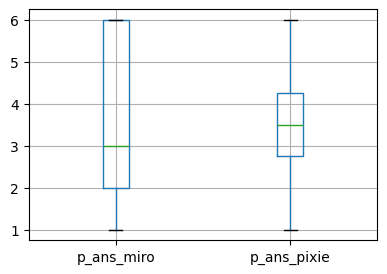

In [65]:
total_pacing_boxplot = data_df.boxplot(column=total_counts_pacing, figsize=(4.5, 3))

In [66]:
wilc_total_pacing = wilcoxon(data_df['p_ans_miro'], data_df['p_ans_pixie'])
wilc_total_pacing.statistic, wilc_total_pacing.pvalue

(96.5, 0.7473513186644183)

In [67]:
lev_total_pacing = levene(data_df['p_ans_miro'], data_df['p_ans_pixie'])
lev_total_pacing.statistic, lev_total_pacing.pvalue

(0.7353463587921849, 0.39560155462370694)

#### By Tool and Whiteboard Experience

In [68]:
data_exp_yes = data_df.loc[data_df['Whiteboard Experience Codified'] == 1]
data_exp_no = data_df.loc[data_df['Whiteboard Experience Codified'] == 0]

Text(0.5, 0.98, '')

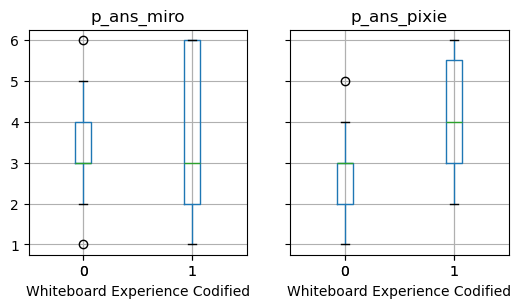

In [69]:
total_pacing_boxplot_by_wb_exp = data_df.boxplot(column=total_counts_pacing, by='Whiteboard Experience Codified', figsize=(6,3))
plt.suptitle('')

In [70]:
wilc_total_pacing_wb_exp = wilcoxon(data_exp_yes['p_ans_pixie'], data_exp_yes['p_ans_miro'], alternative='greater')
wilc_total_pacing_wb_exp.statistic, wilc_total_pacing_wb_exp.pvalue

(38.0, 0.325888948764388)

In [71]:
wilc_total_pacing_no_wb_exp = wilcoxon(data_exp_no['p_ans_pixie'], data_exp_no['p_ans_miro'], alternative='less')
wilc_total_pacing_no_wb_exp.statistic, wilc_total_pacing_no_wb_exp.pvalue

(15.0, 0.20703125)

*x*: answers in pixie *with* whiteboard experience
*y*: answers in pixie *without* whiteboard experience

$H_0$: the distribution underlying x is not stochastically greater than (i.e. is smaller than or equal to) the distribution underlying y

$H_{alt}$: the distribution underlying x is stochastically greater than the distribution underlying y, i.e. SX(u) > SY(u) for all u

In [72]:


mwu_pixie_answers_wb_exp = mannwhitneyu(data_exp_yes['p_ans_pixie'], data_exp_no['p_ans_pixie'], alternative='greater')
mwu_pixie_answers_wb_exp.statistic, mwu_pixie_answers_wb_exp.pvalue

(103.5, 0.015198521622538362)

In [73]:
data_exp_yes['p_ans_pixie'].median()

4.0

In [74]:
data_exp_no['p_ans_pixie'].median()

3.0

#### By Tool and Miro Usage

In [75]:
data_usage_yes = data_df.loc[data_df['p_used_miro'] == 1]
data_usage_no = data_df.loc[data_df['p_used_miro'] == 0]

Text(0.5, 0.98, '')

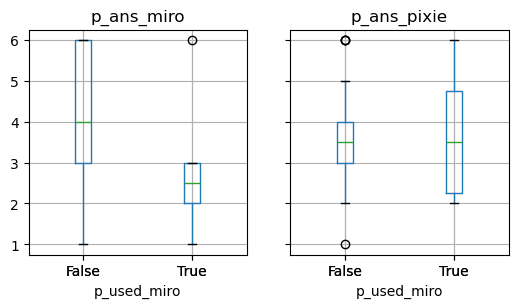

In [76]:
total_pacing_boxplot_by_miro_usage = data_df.boxplot(column=total_counts_pacing, by='p_used_miro', figsize=(6,3))
plt.suptitle('')

In [77]:
data_df[['Whiteboard Experience Codified', 'p_used_miro']].corr()

,Whiteboard Experience Codified,p_used_miro
Whiteboard Experience Codified,1.000000,0.447214
p_used_miro,0.447214,1.000000


In [78]:
wilc_total_pacing_by_miro_usage = wilcoxon(data_usage_yes['p_ans_pixie'], data_usage_yes['p_ans_miro'], alternative='greater')
wilc_total_pacing_by_miro_usage.statistic, wilc_total_pacing_by_miro_usage.pvalue

(11.0, 0.1875)

*x*: correct answers in Miro *with* Miro functionality usage

*y*: correct answers in Miro *without* Miro functionality usage

$H_0$: the distribution underlying x is not stochastically less than (i.e. is greater than or equal to) the distribution underlying y

$H_{alt}$: the distribution underlying x is stochastically less than the distribution underlying y, i.e. SX(u) > SY(u) for all u

In [79]:
mwu_miro_total_miro_usage = mannwhitneyu(data_usage_yes['p_ans_miro'], data_usage_no['p_ans_miro'], alternative='less')
mwu_miro_total_miro_usage.statistic, mwu_miro_total_miro_usage.pvalue

(32.5, 0.07540184146884174)

In [80]:
data_usage_yes['p_ans_miro'].median()

2.5

In [81]:
data_usage_no['p_ans_miro'].median()

4.0

#### DIff Between Tools

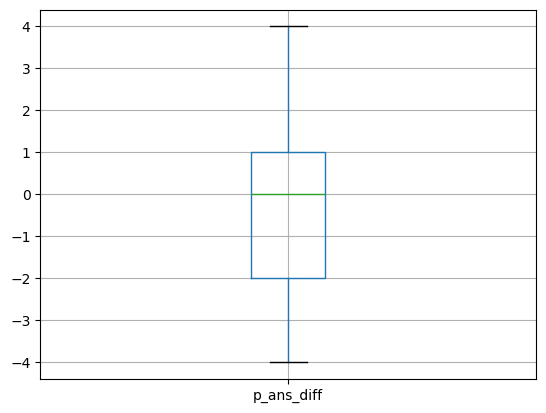

In [82]:
data_df['p_ans_diff'] = data_df['p_ans_pixie'] - data_df['p_ans_miro']
pacing_diff = data_df.boxplot(column=['p_ans_diff'])

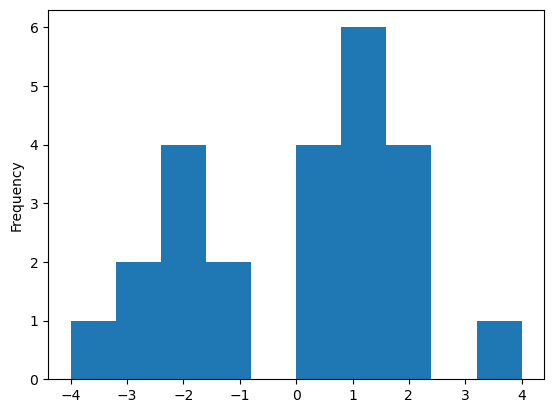

In [83]:
pacing_diff_hist = data_df['p_ans_diff'].plot.hist()

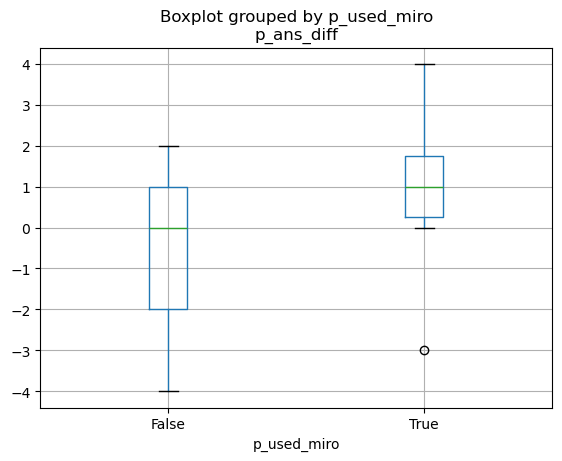

In [84]:
pacing_total_by_miro_usage = data_df.boxplot(column=['p_ans_diff'], by='p_used_miro')

#### Diff By Whiteboard Experience

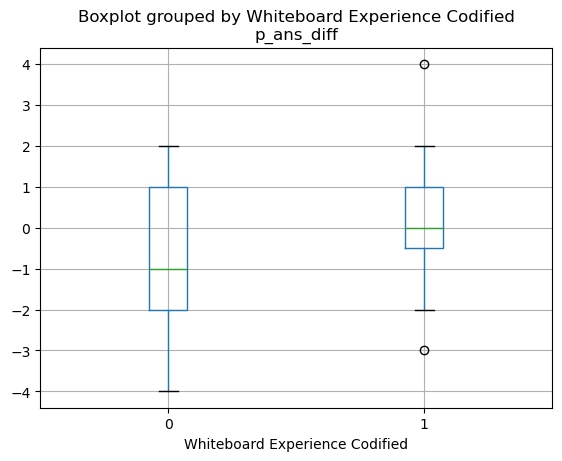

In [85]:
pacing_diff_by_wb_exp = data_df.boxplot(column=['p_ans_diff'], by="Whiteboard Experience Codified")

#### By Group

Text(0.5, 0.98, '')

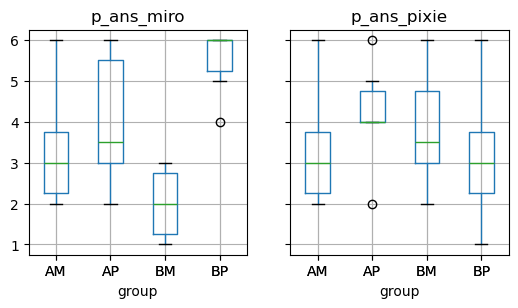

In [86]:
total_pacing_by_group_boxplot = data_df.boxplot(column=total_counts_pacing, by='group', figsize=(6, 3))
plt.suptitle('')

In [87]:
data_df_am = data_df[data_df['group'] == 'AM']
data_df_ap = data_df[data_df['group'] == 'AP']
data_df_bm = data_df[data_df['group'] == 'BM']
data_df_bp = data_df[data_df['group'] == 'BP']

In [88]:
kruskal_ans_groups_miro = kruskal(
    data_df_am['p_ans_miro'],
    data_df_ap['p_ans_miro'],
    data_df_bm['p_ans_miro'],
    data_df_bp['p_ans_miro'],
)
kruskal_ans_groups_miro.statistic, kruskal_ans_groups_miro.pvalue

(12.251221001220992, 0.006570308655445982)

In [89]:
dunns_ans_posthoc = posthoc_dunn(data_df, val_col='p_ans_miro', group_col='group', p_adjust='holm')
dunns_ans_posthoc

,AM,AP,BM,BP
AM,1.000000,0.502654,0.500423,0.200434
AP,0.502654,1.000000,0.200434,0.500423
BM,0.500423,0.200434,1.000000,0.003550
BP,0.200434,0.500423,0.003550,1.000000


In [90]:
(kruskal_ans_groups_miro.statistic - 6 + 1)/(24 - 6)

0.402845611178944

In [91]:
kruskal_ans_groups_pixie = kruskal(
    data_df_am['p_ans_pixie'],
    data_df_ap['p_ans_pixie'],
    data_df_bm['p_ans_pixie'],
    data_df_bp['p_ans_pixie'],
)
kruskal_ans_groups_pixie.statistic, kruskal_ans_groups_pixie.pvalue

(2.1110353190844298, 0.54968347133725)

In [92]:
(kruskal_ans_groups_pixie.statistic - 6 + 1)/(24 - 6)

-0.1604980378286428

#### By First Tool

Text(0.5, 0.98, '')

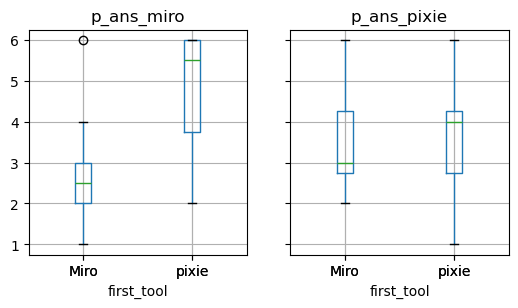

In [93]:
pacing_ans_by_first_tool = data_df.boxplot(column=['p_ans_miro', 'p_ans_pixie'], by='first_tool', figsize=(6, 3))
plt.suptitle('')

In [94]:
data_miro_first = data_df.loc[data_df['first_tool'] == 'Miro']
data_pixie_first = data_df.loc[data_df['first_tool'] == 'pixie']

In [95]:
mwu_pixie_ans_first_tool = mannwhitneyu(data_miro_first['p_ans_pixie'], data_pixie_first['p_ans_pixie'], alternative='less')
mwu_pixie_ans_first_tool.statistic, mwu_pixie_ans_first_tool.pvalue

(67.5, 0.4066449063647648)

In [96]:
mwu_miro_ans_first_tool = mannwhitneyu(data_miro_first['p_ans_miro'], data_pixie_first['p_ans_miro'], alternative='less')
mwu_miro_ans_first_tool.statistic, mwu_miro_ans_first_tool.pvalue

(23.0, 0.002029436083361975)

In [97]:
mwu_ans_miro_first = mannwhitneyu(data_miro_first['p_ans_miro'], data_miro_first['p_ans_pixie'], alternative='less')
mwu_ans_miro_first.statistic, mwu_ans_miro_first.pvalue

(45.0, 0.05681543858294864)

In [98]:
mwu_ans_pixie_first = mannwhitneyu(data_pixie_first['p_ans_miro'], data_pixie_first['p_ans_pixie'], alternative='greater')
mwu_ans_pixie_first.statistic, mwu_ans_pixie_first.pvalue

(99.5, 0.0540994690430847)

#### By First Task Version

Text(0.5, 0.98, '')

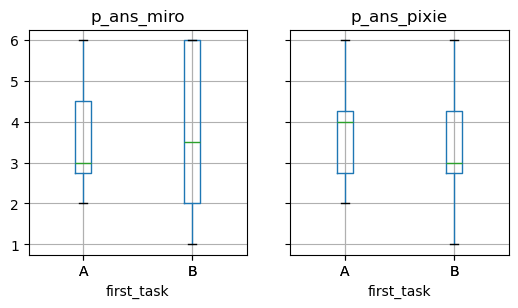

In [144]:
pacing_ans_by_first_task = data_df.boxplot(column=['p_ans_miro', 'p_ans_pixie'], by='first_task', figsize=(6, 3))
plt.suptitle('')

In [145]:
data_a_first = data_df.loc[data_df['first_task'] == 'A']
data_b_first = data_df.loc[data_df['first_task'] == 'B']

mwu_pixie_ans_first_task = mannwhitneyu(data_a_first['p_ans_pixie'], data_b_first['p_ans_pixie'], alternative='two-sided')
mwu_pixie_ans_first_task.statistic, mwu_pixie_ans_first_task.pvalue

(79.5, 0.679370578356138)

In [147]:
mwu_miro_ans_first_task = mannwhitneyu(data_a_first['p_ans_miro'], data_b_first['p_ans_miro'], alternative='two-sided')
mwu_miro_ans_first_task.statistic, mwu_miro_ans_first_task.pvalue

(72.0, 1.0)

In [149]:
mwu_ans_a_first = mannwhitneyu(data_a_first['p_ans_miro'], data_a_first['p_ans_pixie'], alternative='two-sided')
mwu_ans_a_first.statistic, mwu_ans_a_first.pvalue

(67.5, 0.8122816289421281)

In [151]:
mwu_ans_b_first = mannwhitneyu(data_b_first['p_ans_miro'], data_b_first['p_ans_pixie'], alternative='two-sided')
mwu_ans_b_first.statistic, mwu_ans_b_first.pvalue

(76.5, 0.8137878518872259)

### Right Answers

#### By Tool

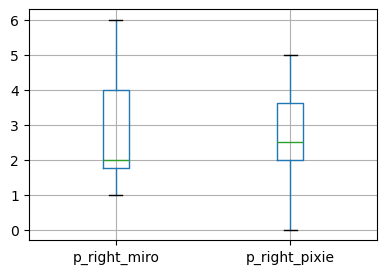

In [99]:
pacing_rights = data_df.boxplot(column=['p_right_miro', 'p_right_pixie'], figsize=(4.5, 3))

In [100]:
wilc_right_pacing = wilcoxon(data_df['p_right_miro'], data_df['p_right_pixie'])
wilc_right_pacing.statistic, wilc_right_pacing.pvalue

(98.5, 0.8058983773663436)

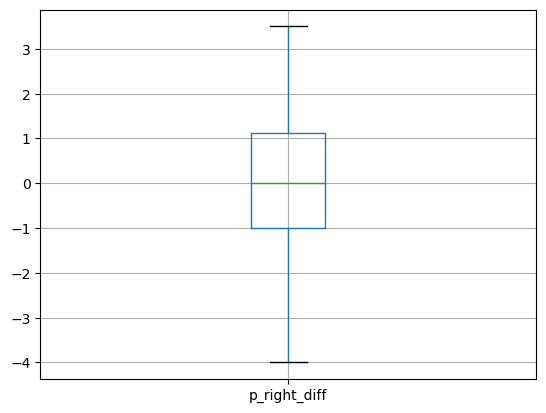

In [101]:
data_df['p_right_diff'] = data_df['p_right_pixie'] - data_df['p_right_miro']
pacing_right_diff = data_df.boxplot(column=['p_right_diff'])

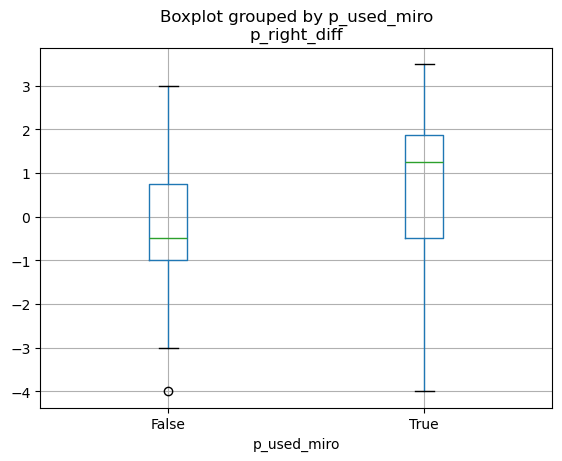

In [102]:
pacing_right_diff_by_miro_usage = data_df.boxplot(column=['p_right_diff'], by='p_used_miro')

In [103]:
data_df[['p_right_miro', 'p_right_pixie']].describe()

,p_right_miro,p_right_pixie
count,24.000000,24.000000
mean,2.791667,2.625000
std,1.718927,1.353337
min,1.000000,0.000000
25%,1.750000,2.000000
50%,2.000000,2.500000
75%,4.000000,3.625000
max,6.000000,5.000000


#### By Tool and Whiteboard Experience

In [104]:
data_exp_yes = data_df.loc[data_df['Whiteboard Experience Codified'] == 1]
data_exp_no = data_df.loc[data_df['Whiteboard Experience Codified'] == 0]

Text(0.5, 0.98, '')

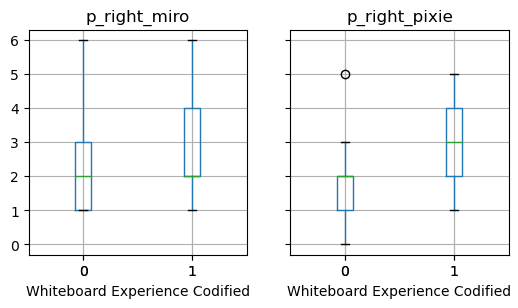

In [105]:
pacing_rights_by_wb_exp = data_df.boxplot(column=['p_right_miro', 'p_right_pixie'], by='Whiteboard Experience Codified', figsize=(6, 3))
plt.suptitle('')

In [106]:
wilc_right_pacing_wb_exp = wilcoxon(data_exp_yes['p_right_miro'], data_exp_yes['p_right_pixie'])
wilc_right_pacing_wb_exp.statistic, wilc_right_pacing_wb_exp.pvalue

(39.0, 0.6434989459129046)

In [107]:
wilc_right_pacing_no_wb_exp = wilcoxon(data_exp_no['p_right_miro'], data_exp_no['p_right_pixie'])
wilc_right_pacing_no_wb_exp.statistic, wilc_right_pacing_wb_exp.pvalue

(9.0, 0.6434989459129046)

*x*: correct answers in pixie *with* whiteboard experience

*y*: acorrect nswers in pixie *without* whiteboard experience

$H_0$: the distribution underlying x is not stochastically greater than (i.e. is smaller than or equal to) the distribution underlying y

$H_{alt}$: the distribution underlying x is stochastically greater than the distribution underlying y, i.e. SX(u) > SY(u) for all u

In [108]:
mwu_pixie_right_wb_exp = mannwhitneyu(data_exp_yes['p_right_pixie'], data_exp_no['p_right_pixie'], alternative='greater')
mwu_pixie_right_wb_exp.statistic, mwu_pixie_right_wb_exp.pvalue

(103.0, 0.01660439188879628)

In [109]:
data_exp_yes['p_right_pixie'].median()

3.0

In [110]:
data_exp_no['p_right_pixie'].median()

2.0

#### By Tool and Miro Usage

Text(0.5, 0.98, '')

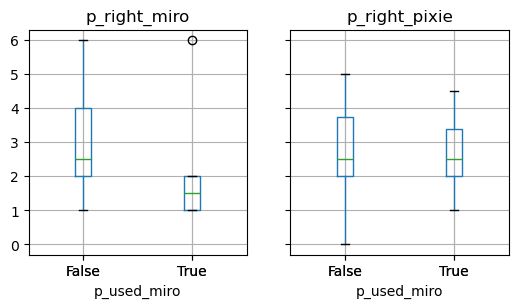

In [111]:
pacing_rights_by_miro_usage = data_df.boxplot(column=['p_right_miro', 'p_right_pixie'], by='p_used_miro', figsize=(6, 3))
plt.suptitle('')

In [112]:
wilc_right_pacing_by_miro_usage = wilcoxon(data_usage_yes['p_right_pixie'], data_usage_yes['p_right_miro'], alternative='greater')
wilc_right_pacing_by_miro_usage.statistic, wilc_right_pacing_by_miro_usage.pvalue

(13.5, 0.296875)

*x*: correct answers in Miro *with* Miro functionality usage

*y*: correct answers in Miro *without* Miro functionality usage

$H_0$: the distribution underlying x is not stochastically less than (i.e. is greater than or equal to) the distribution underlying y

$H_{alt}$: the distribution underlying x is stochastically less than the distribution underlying y, i.e. SX(u) > SY(u) for all u

In [113]:
data_usage_yes = data_df.loc[data_df['p_used_miro'] == 1]
data_usage_no = data_df.loc[data_df['p_used_miro'] == 0]

mwu_miro_right_miro_usage = mannwhitneyu(data_usage_yes['p_right_miro'], data_usage_no['p_right_miro'], alternative='less')
mwu_miro_right_miro_usage.statistic, mwu_miro_right_miro_usage.pvalue

(33.5, 0.08497339144083382)

In [114]:
data_usage_yes['p_right_miro'].median()

1.5

In [115]:
data_usage_no['p_right_miro'].median()

2.5

#### By Group

Text(0.5, 0.98, '')

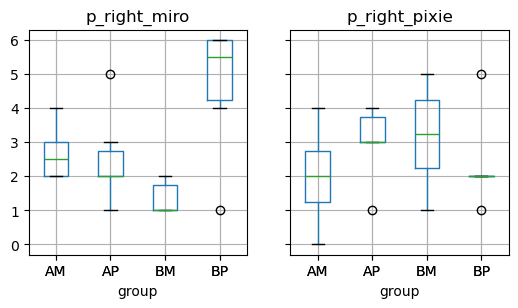

In [116]:
pacing_right_by_group_boxplot = data_df.boxplot(column=['p_right_miro', 'p_right_pixie'], by='group', figsize=(6, 3))
plt.suptitle('')

In [117]:
data_df_am = data_df[data_df['group'] == 'AM']
data_df_ap = data_df[data_df['group'] == 'AP']
data_df_bm = data_df[data_df['group'] == 'BM']
data_df_bp = data_df[data_df['group'] == 'BP']

In [118]:
kruskal_right_groups_miro = kruskal(
    data_df_am['p_right_miro'],
    data_df_ap['p_right_miro'],
    data_df_bm['p_right_miro'],
    data_df_bp['p_right_miro'],
)
kruskal_right_groups_miro.statistic, kruskal_right_groups_miro.pvalue

(10.57124213112236, 0.01428532721234054)

In [119]:
dunns_right_posthoc = posthoc_dunn(data_df, val_col='p_right_miro', group_col='group', p_adjust='holm')
dunns_right_posthoc

,AM,AP,BM,BP
AM,1.000000,0.659059,0.241369,0.430249
AP,0.659059,1.000000,0.375282,0.371200
BM,0.241369,0.375282,1.000000,0.007839
BP,0.430249,0.371200,0.007839,1.000000


In [120]:
(kruskal_right_groups_miro.statistic - 6 + 1)/(24 - 6)

0.30951345172902006

In [121]:
kruskal_right_groups_pixie = kruskal(
    data_df_am['p_right_pixie'],
    data_df_ap['p_right_pixie'],
    data_df_bm['p_right_pixie'],
    data_df_bp['p_right_pixie'],
)
kruskal_right_groups_pixie.statistic, kruskal_right_groups_pixie.pvalue

(3.083672853478187, 0.378903521375986)

In [122]:
(kruskal_right_groups_pixie.statistic - 6 + 1)/(24 - 6)

-0.10646261925121182

#### By First Tool

Text(0.5, 0.98, '')

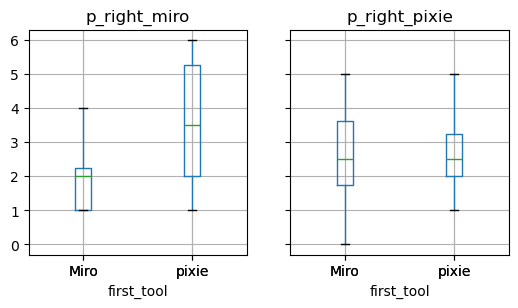

In [152]:
pacing_right_by_first_tool = data_df.boxplot(column=['p_right_miro', 'p_right_pixie'], by='first_tool', figsize=(6, 3))
plt.suptitle('')

In [153]:
data_miro_first = data_df.loc[data_df['first_tool'] == 'Miro']
data_pixie_first = data_df.loc[data_df['first_tool'] == 'pixie']

In [ ]:
mwu_pixie_right_first_tool = mannwhitneyu(data_miro_first['p_right_pixie'], data_pixie_first['p_right_pixie'], alternative='two-sided')
mwu_pixie_right_first_tool.statistic, mwu_pixie_right_first_tool.pvalue

(67.5, 0.4066449063647648)

In [154]:
mwu_miro_right_first_tool = mannwhitneyu(data_miro_first['p_right_miro'], data_pixie_first['p_right_miro'], alternative='less')
mwu_miro_right_first_tool.statistic, mwu_miro_right_first_tool.pvalue

(39.0, 0.02672105822828704)

In [155]:
mwu_right_miro_first = mannwhitneyu(data_miro_first['p_right_miro'], data_miro_first['p_right_pixie'], alternative='less')
mwu_right_miro_first.statistic, mwu_right_miro_first.pvalue

(54.0, 0.1491264868437212)

In [158]:
mwu_right_pixie_first = mannwhitneyu(data_pixie_first['p_right_miro'], data_pixie_first['p_right_pixie'], alternative='greater')
mwu_right_pixie_first.statistic, mwu_right_pixie_first.pvalue

(90.5, 0.14464038478419228)

#### By First Task Version

Text(0.5, 0.98, '')

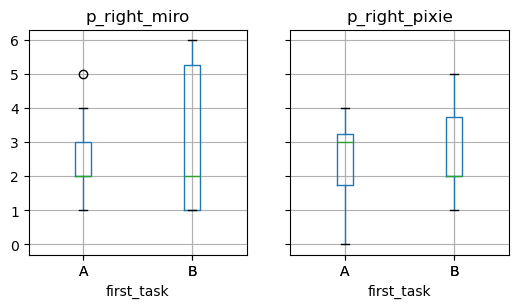

In [159]:
pacing_right_by_first_task = data_df.boxplot(column=['p_right_miro', 'p_right_pixie'], by='first_task', figsize=(6, 3))
plt.suptitle('')

In [160]:
data_a_first = data_df.loc[data_df['first_task'] == 'A']
data_b_first = data_df.loc[data_df['first_task'] == 'B']

mwu_pixie_right_first_task = mannwhitneyu(data_a_first['p_right_pixie'], data_b_first['p_right_pixie'], alternative='two-sided')
mwu_pixie_right_first_task.statistic, mwu_pixie_right_first_task.pvalue

(68.0, 0.8366403188693354)

In [161]:
mwu_miro_right_first_task = mannwhitneyu(data_a_first['p_right_miro'], data_b_first['p_right_miro'], alternative='two-sided')
mwu_miro_right_first_task.statistic, mwu_miro_right_first_task.pvalue

(75.5, 0.858505661180176)

In [162]:
mwu_right_a_first = mannwhitneyu(data_a_first['p_right_miro'], data_a_first['p_right_pixie'], alternative='two-sided')
mwu_right_a_first.statistic, mwu_right_a_first.pvalue

(69.5, 0.9048464231390124)

In [163]:
mwu_right_b_first = mannwhitneyu(data_b_first['p_right_miro'], data_b_first['p_right_pixie'], alternative='two-sided')
mwu_right_b_first.statistic, mwu_right_b_first.pvalue

(70.0, 0.9291183341533812)

### Wrong Answers

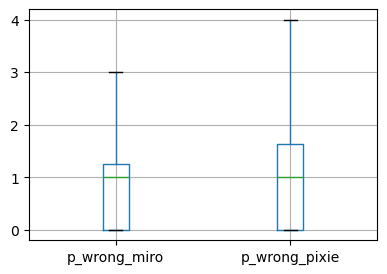

In [123]:
data_df['p_wrong_pixie'] = data_df['p_ans_pixie'] - data_df['p_right_pixie']
data_df['p_wrong_miro'] = data_df['p_ans_miro'] - data_df['p_right_miro']
pacing_wrongs = data_df.boxplot(column=['p_wrong_miro', 'p_wrong_pixie'], figsize=(4.5, 3))

In [124]:
wilc_wrong_pacing = wilcoxon(data_df['p_wrong_miro'], data_df['p_wrong_pixie'])
wilc_wrong_pacing.statistic, wilc_wrong_pacing.pvalue

(53.5, 0.7022608974564812)

In [125]:
data_df[['p_wrong_miro', 'p_wrong_pixie']].describe()

,p_wrong_miro,p_wrong_pixie
count,24.000000,24.000000
mean,0.916667,1.000000
std,0.974308,1.073394
min,0.000000,0.000000
25%,0.000000,0.000000
50%,1.000000,1.000000
75%,1.250000,1.625000
max,3.000000,4.000000


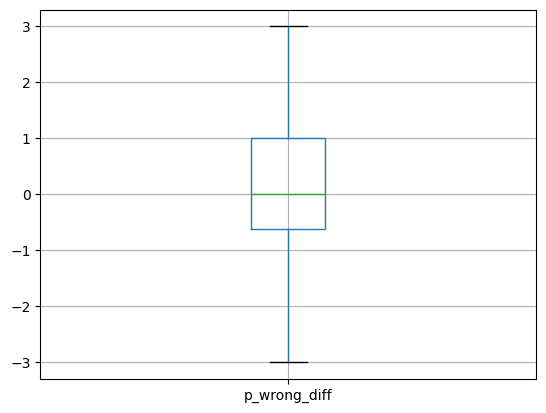

In [126]:
data_df['p_wrong_diff'] = data_df['p_wrong_pixie'] - data_df['p_wrong_miro']
pacing_wrongs = data_df.boxplot(column=['p_wrong_diff'])

In [127]:
data_df['p_wrong_diff'].describe()

count    24.000000
mean      0.083333
std       1.185663
min      -3.000000
25%      -0.625000
50%       0.000000
75%       1.000000
max       3.000000
Name: p_wrong_diff, dtype: float64

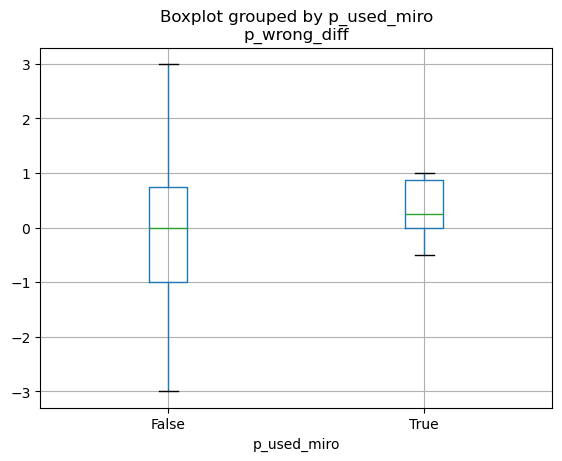

In [128]:
pacing_diff_by_miro_usage = data_df.boxplot(column=['p_wrong_diff'], by='p_used_miro')

Text(0.5, 0.98, '')

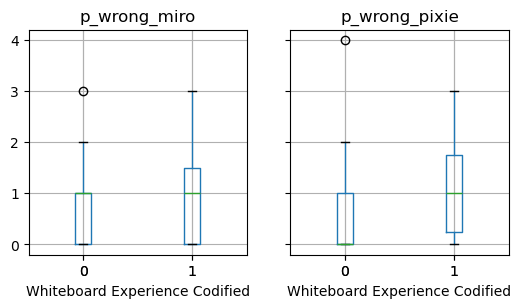

In [129]:
pacing_wrongs_by_wb_exp = data_df.boxplot(column=['p_wrong_miro', 'p_wrong_pixie'], by='Whiteboard Experience Codified', figsize=(6, 3))
plt.suptitle('')

Text(0.5, 0.98, '')

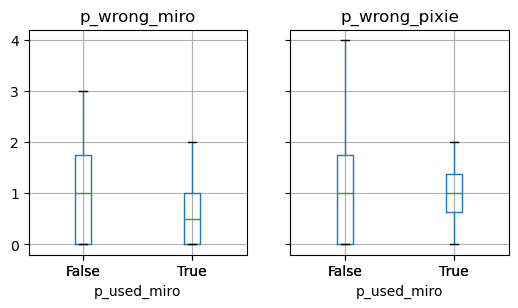

In [130]:
pacing_wrongs_by_miro_usage = data_df.boxplot(column=['p_wrong_miro', 'p_wrong_pixie'], by='p_used_miro', figsize=(6, 3))
plt.suptitle('')

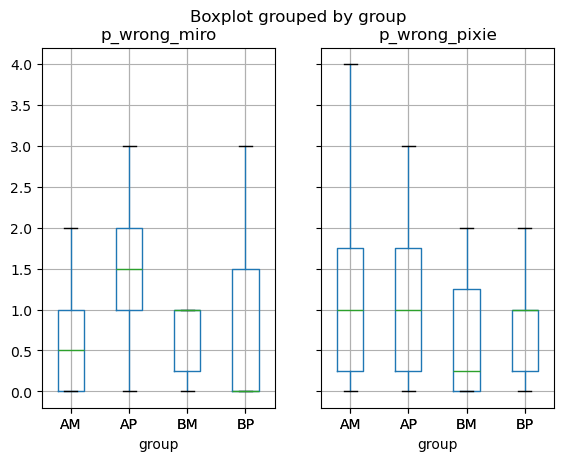

In [131]:
pacing_wrongs_grouped = data_df.boxplot(column=['p_wrong_miro', 'p_wrong_pixie'], by='group')

## Comparison Between Tasks

In [132]:
data_df['p_right_a'] = 'Default'
data_df['p_right_a'] = data_df['p_right_a'].case_when(
    [
        (data_df['group'] == 'AM', data_df['p_right_miro']),
        (data_df['group'] == 'AP', data_df['p_right_pixie']),
        (data_df['group'] == 'BM', data_df['p_right_pixie']),
        (data_df['group'] == 'BP', data_df['p_right_miro']),
    ]
)

data_df['p_right_b'] = 'Default'
data_df['p_right_b'] = data_df['p_right_b'].case_when(
    [
        (data_df['group'] == 'AM', data_df['p_right_pixie']),
        (data_df['group'] == 'AP', data_df['p_right_miro']),
        (data_df['group'] == 'BM', data_df['p_right_miro']),
        (data_df['group'] == 'BP', data_df['p_right_pixie']),
    ]
)

data_df['p_wrong_a'] = 'Default'
data_df['p_wrong_a'] = data_df['p_wrong_a'].case_when(
    [
        (data_df['group'] == 'AM', data_df['p_wrong_miro']),
        (data_df['group'] == 'AP', data_df['p_wrong_pixie']),
        (data_df['group'] == 'BM', data_df['p_wrong_pixie']),
        (data_df['group'] == 'BP', data_df['p_wrong_miro']),
    ]
)

data_df['p_wrong_b'] = 'Default'
data_df['p_wrong_b'] = data_df['p_wrong_b'].case_when(
    [
        (data_df['group'] == 'AM', data_df['p_wrong_pixie']),
        (data_df['group'] == 'AP', data_df['p_wrong_miro']),
        (data_df['group'] == 'BM', data_df['p_wrong_miro']),
        (data_df['group'] == 'BP', data_df['p_wrong_pixie']),
    ]
)

data_df['p_ans_a'] = 'Default'
data_df['p_ans_a'] = data_df['p_ans_a'].case_when(
    [
        (data_df['group'] == 'AM', data_df['p_ans_miro']),
        (data_df['group'] == 'AP', data_df['p_ans_pixie']),
        (data_df['group'] == 'BM', data_df['p_ans_pixie']),
        (data_df['group'] == 'BP', data_df['p_ans_miro']),
    ]
)

data_df['p_ans_b'] = 'Default'
data_df['p_ans_b'] = data_df['p_ans_b'].case_when(
    [
        (data_df['group'] == 'AM', data_df['p_ans_pixie']),
        (data_df['group'] == 'AP', data_df['p_ans_miro']),
        (data_df['group'] == 'BM', data_df['p_ans_miro']),
        (data_df['group'] == 'BP', data_df['p_ans_pixie']),
    ]
)
data_df[['p_right_a', 'p_right_b', 'p_wrong_a', 'p_wrong_b', 'p_ans_a', 'p_ans_b']] = data_df[['p_right_a', 'p_right_b', 'p_wrong_a', 'p_wrong_b', 'p_ans_a', 'p_ans_b']].apply(pd.to_numeric)
data_df

,participant,p_id,date,group,s_iss_miro,s_tp_miro,s_fp_miro,s_iss_pixie,s_tp_pixie,s_fp_pixie,...,p_right_diff,p_wrong_pixie,p_wrong_miro,p_wrong_diff,p_right_a,p_right_b,p_wrong_a,p_wrong_b,p_ans_a,p_ans_b
0,1,MA12534,2026-06-29,AM,3,2,1,0,0,0,...,1.0,0.0,0,0.0,2.0,3.0,0.0,0.0,2,3
1,21,MA26593,2026-07-07,AM,1,1,0,0,0,0,...,-2.0,4.0,1,3.0,2.0,0.0,1.0,4.0,3,4
2,13,MA34230,2026-07-01,AM,3,3,0,1,1,0,...,0.0,2.0,2,0.0,4.0,4.0,2.0,2.0,6,6
3,5,MA7125,2026-06-30,AM,4,1,3,2,2,0,...,-1.0,1.0,1,0.0,3.0,2.0,1.0,1.0,4,3
4,17,MA95137,2026-07-02,AM,2,2,0,0,0,0,...,-1.0,0.0,0,0.0,3.0,2.0,0.0,0.0,3,2
5,9,MA95935,2026-06-30,AM,2,1,1,0,0,0,...,-1.0,1.0,0,1.0,2.0,1.0,0.0,1.0,2,2
6,15,MB10509,2026-07-02,BM,2,2,0,1,1,1,...,3.0,0.0,1,-1.0,5.0,2.0,0.0,1.0,5,3
7,7,MB24145,2026-06-30,BM,3,3,0,2,1,1,...,0.0,2.0,0,2.0,1.0,1.0,2.0,0.0,3,1
8,23,MB41880,2026-07-07,BM,1,1,0,0,0,0,...,2.0,0.0,1,-1.0,3.0,1.0,0.0,1.0,3,2
9,11,MB50964,2026-07-01,BM,2,2,0,4,2,2,...,1.0,0.0,0,0.0,2.0,1.0,0.0,0.0,2,1


In [133]:
print(data_df.dtypes)

participant      int64
p_id               str
date               str
group              str
s_iss_miro       int64
                ...   
p_right_b      float64
p_wrong_a      float64
p_wrong_b      float64
p_ans_a          int64
p_ans_b          int64
Length: 70, dtype: object


In [134]:
data_df['p_right_a'].describe()

count    24.000000
mean      3.375000
std       1.534034
min       1.000000
25%       2.000000
50%       3.000000
75%       4.125000
max       6.000000
Name: p_right_a, dtype: float64

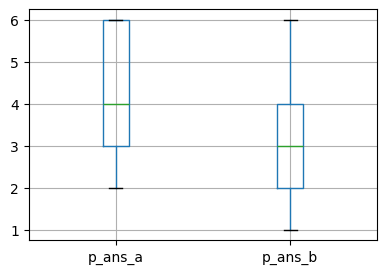

In [135]:
total_pacing_boxplot_tasks = data_df.boxplot(column=['p_ans_a', 'p_ans_b'], figsize=(4.5, 3))

In [136]:
wilc_ans_a_vs_b = wilcoxon(
    data_df['p_ans_a'], 
    data_df['p_ans_b'],
    alternative='greater'
)
wilc_ans_a_vs_b.statistic, wilc_ans_a_vs_b.pvalue

(176.0, 0.003564421270173578)

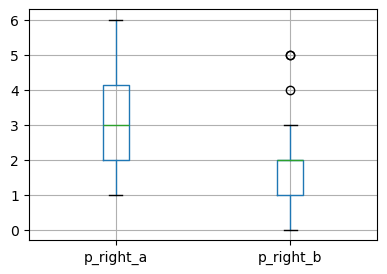

In [137]:
right_pacing_boxplot_tasks = data_df.boxplot(column=['p_right_a', 'p_right_b'], figsize=(4.5, 3))

In [138]:
wilc_right_a_vs_b = wilcoxon(
    data_df['p_right_a'], 
    data_df['p_right_b'],
    alternative='greater'
)
wilc_right_a_vs_b.statistic, wilc_right_a_vs_b.pvalue

(195.0, 0.0003341210561220924)

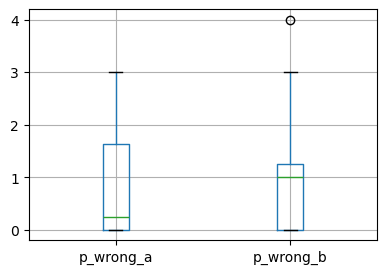

In [139]:
wrong_pacing_boxplot_tasks = data_df.boxplot(column=['p_wrong_a', 'p_wrong_b'], figsize=(4.5, 3))

In [140]:
wilc_wrong_a_vs_b = wilcoxon(
    data_df['p_wrong_a'], 
    data_df['p_wrong_b'],
    alternative='two-sided'
)
wilc_wrong_a_vs_b.statistic, wilc_wrong_a_vs_b.pvalue

(36.5, 0.1669550946540571)

## Timeseries

In [141]:
timeseries_data_df = pd.read_csv('../ma-eval/time_series/all.csv')
timeseries_data_df

,p_id,group,task,map,timestamp,tag,note,timedelta
0,PA40344,AP,solvability_pixie,LA_3,01:27:30,STA,NaN,0
1,PA40344,AP,solvability_pixie,LA_3,01:27:44,OBS,pathfinding start-room after boss,14
2,PA40344,AP,solvability_pixie,LA_3,01:28:08,vb,ath blocked to boss,38
3,PA40344,AP,solvability_pixie,LA_3,01:28:45,OBS,successive pathfinding,75
4,PA40344,AP,solvability_pixie,LA_3,01:28:56,vb,oftlock 14,86
...,...,...,...,...,...,...,...,...
819,PA38184,AP,pacing_miro,LA_2,14:43:59,Q2A,R A takes longer than B,162
820,PA38184,AP,pacing_miro,LA_2,14:44:08,Q4A,R room 15,171
821,PA38184,AP,pacing_miro,LA_2,14:45:09,Q3A,"W no, B has more enemies than C",232
822,PA38184,AP,pacing_miro,LA_2,14:46:07,Q5A,? 21-2 to 21-3,290


#### Timeseries: Answers

In [142]:
answers_data_df = timeseries_data_df[timeseries_data_df['tag'].isin(['Q1A', 'Q2A', 'Q3A', 'Q4A', 'Q5A', 'Q6A'])]
answers_data_df

,p_id,group,task,map,timestamp,tag,note,timedelta
11,PA40344,AP,pacing_pixie,LA_1,01:43:52,Q1A,R not steadily increasing,41
12,PA40344,AP,pacing_pixie,LA_1,01:45:10,Q2A,R b shorter than a,119
13,PA40344,AP,pacing_pixie,LA_1,01:45:36,Q3A,W more enemies in b than c,145
14,PA40344,AP,pacing_pixie,LA_1,01:46:51,Q4A,W miniboss 18 or 7,220
15,PA40344,AP,pacing_pixie,LA_1,01:47:17,Q5A,W 9-3 to 5 sharpest increase,246
...,...,...,...,...,...,...,...,...
813,PA38184,AP,pacing_pixie,LA_1,14:37:13,Q2A,? same length,124
819,PA38184,AP,pacing_miro,LA_2,14:43:59,Q2A,R A takes longer than B,162
820,PA38184,AP,pacing_miro,LA_2,14:44:08,Q4A,R room 15,171
821,PA38184,AP,pacing_miro,LA_2,14:45:09,Q3A,"W no, B has more enemies than C",232


##### Distribution of Answer Events Across Time

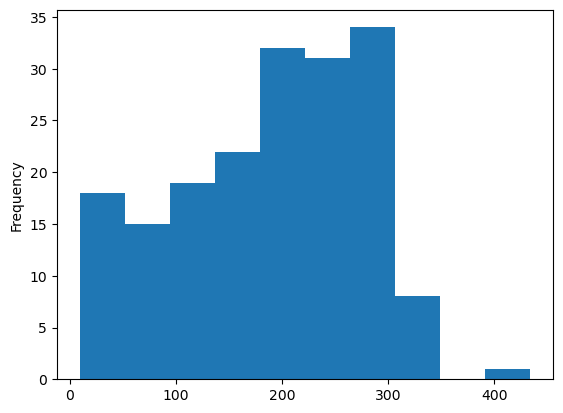

In [143]:
ax3 = answers_data_df['timedelta'].plot.hist()